# 🎬 IMDB Sentiment Analysis — NLP Preprocessing


## 📦 Step 1 Import Libraries

In [1]:
# Install required libraries
!pip install nltk -q

import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split


# Download NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📂 Step 2 — Load Dataset


In [2]:
#  # ارفع الـ CSV مباشرة من هنا
#  from google.colab import files
# uploaded = files.upload()  # هيفتح نافذة اختيار ملف

#  import io
#  filename = list(uploaded.keys())[0]
#  df = pd.read_csv(io.BytesIO(uploaded[filename]))

#  print(f'📊 Dataset Shape: {df.shape}')
#  print(f'📋 Columns: {df.columns.tolist()}')
#  print(f'\n🏷️  Sentiment Distribution:')
#  print(df['sentiment'].value_counts())
#  print(f'\n🔍 Sample Review:')
#  print(df['review'].iloc[0][:300])

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
folder_id = '1Zg7OuuhwnsPOvTjOD5AO7O5nUzpxCYhV'
folder_path = '/content/drive/MyDrive'

# Find the CSV automatically
csv_file = None
for root, dirs, files in os.walk(folder_path):
    for f in files:
        if 'IMDB' in f and f.endswith('.csv'):
            csv_file = os.path.join(root, f)
            break

# Direct path fallback
if csv_file is None:
    csv_file = '/content/drive/MyDrive/1778101724498_IMDB_Dataset_CLEANED.csv'

df = pd.read_csv(csv_file)

print(f'📊 Dataset Shape: {df.shape}')
print(f'📋 Columns: {df.columns.tolist()}')
print(f'\n🏷️  Sentiment Distribution:')
print(df['sentiment'].value_counts())
print(f'\n🔍 Sample Review:')
print(df['review'].iloc[0][:300])

Mounted at /content/drive
📊 Dataset Shape: (49396, 2)
📋 Columns: ['review', 'sentiment']

🏷️  Sentiment Distribution:
sentiment
negative    24698
positive    24698
Name: count, dtype: int64

🔍 Sample Review:
$25,000 Pyramid Clues: Deep Blue Sea. Tremors. Slither. Eight Legged Freaks.<br /><br />Pyramid Category: Movies that were funnier and more thrilling than Snakes on a Plane.<br /><br />Hell, with that definition I'd have to include the relatively harrowing journey of Ted and Elaine in Airplane! as s


## 🔢 Step 3 — Encode Labels

In [4]:
# Convert sentiment to binary: positive=1, negative=0
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print('✅ Label encoding done:')
print(df[['sentiment', 'label']].value_counts())
df.head(3)

✅ Label encoding done:
sentiment  label
negative   0        24698
positive   1        24698
Name: count, dtype: int64


,review,sentiment,label
0,"$25,000 Pyramid Clues: Deep Blue Sea. Tremors....",negative,0
1,0.5/10. This movie has absolutely nothing good...,negative,0
2,"0*'s Christian Slater, Tara Reid, Stephen Dorf...",negative,0


## 🧹 Step 4 — Text Cleaning Pipeline

الخطوات:
1. إزالة HTML tags
2. تحويل لـ lowercase
3. إزالة الأرقام والرموز
4. إزالة المسافات الزيادة

In [5]:
def clean_text(text):
    """Step 4: Clean raw review text."""
    # 4.1 Remove HTML tags (e.g. <br />, <b>, </b>)
    text = re.sub(r'<.*?>', ' ', text)

    # 4.2 Lowercase everything
    text = text.lower()

    # 4.3 Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # 4.4 Remove numbers
    text = re.sub(r'\d+', '', text)

    # 4.5 Keep only letters and spaces (remove punctuation & special chars)
    text = re.sub(r"[^a-z\s]", '', text)

    # 4.6 Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply cleaning
df['cleaned'] = df['review'].apply(clean_text)

# Show before vs after
print('--- BEFORE ---')
print(df['review'].iloc[0][:250])
print('\n--- AFTER ---')
print(df['cleaned'].iloc[0][:250])

--- BEFORE ---
$25,000 Pyramid Clues: Deep Blue Sea. Tremors. Slither. Eight Legged Freaks.<br /><br />Pyramid Category: Movies that were funnier and more thrilling than Snakes on a Plane.<br /><br />Hell, with that definition I'd have to include the relatively har

--- AFTER ---
pyramid clues deep blue sea tremors slither eight legged freaks pyramid category movies that were funnier and more thrilling than snakes on a plane hell with that definition id have to include the relatively harrowing journey of ted and elaine in air


## ✂️ Step 5 — Tokenization

In [6]:
def tokenize(text):
    """Step 5: Split text into list of words (tokens)."""
    return word_tokenize(text)

df['tokens'] = df['cleaned'].apply(tokenize)

print('✅ Tokenization done!')
print(f'\nSample tokens ({len(df["tokens"].iloc[0])} words):')
print(df['tokens'].iloc[0][:20])

✅ Tokenization done!

Sample tokens (183 words):
['pyramid', 'clues', 'deep', 'blue', 'sea', 'tremors', 'slither', 'eight', 'legged', 'freaks', 'pyramid', 'category', 'movies', 'that', 'were', 'funnier', 'and', 'more', 'thrilling', 'than']


## 🚫 Step 6 — Remove Stopwords

In [7]:
STOPWORDS = set(stopwords.words('english'))
# words like 'not', 'no', 'nor' can flip the meaning
negation_words = {'not', 'no', 'nor', 'never', "n't", 'neither', 'nobody', 'nothing', 'nowhere'}
STOPWORDS -= negation_words

def remove_stopwords(tokens):
    """Step 6: Remove stopwords but keep negation words."""
    return [word for word in tokens if word not in STOPWORDS]

df['tokens_no_sw'] = df['tokens'].apply(remove_stopwords)

# Show reduction in token count
avg_before = df['tokens'].apply(len).mean()
avg_after  = df['tokens_no_sw'].apply(len).mean()
print(f'Average tokens BEFORE stopword removal: {avg_before:.0f}')
print(f'Average tokens AFTER  stopword removal: {avg_after:.0f}')
print(f'Reduction: {(1 - avg_after/avg_before)*100:.1f}%')
print(f'\nSample:')
print(df['tokens_no_sw'].iloc[0][:20])

Average tokens BEFORE stopword removal: 227
Average tokens AFTER  stopword removal: 121
Reduction: 46.8%

Sample:
['pyramid', 'clues', 'deep', 'blue', 'sea', 'tremors', 'slither', 'eight', 'legged', 'freaks', 'pyramid', 'category', 'movies', 'funnier', 'thrilling', 'snakes', 'plane', 'hell', 'definition', 'id']


## 🌿 Step 7 — Lemmatization





In [8]:
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    """Step 7: Lemmatize each token."""
    return [lemmatizer.lemmatize(word) for word in tokens]

df['tokens_lemma'] = df['tokens_no_sw'].apply(lemmatize_tokens)


print('✅ Lemmatization done!')
sample_before = df['tokens_no_sw'].iloc[0][:15]
sample_after  = df['tokens_lemma'].iloc[0][:15]
print('\nBefore → After:')
for b, a in zip(sample_before, sample_after):
    marker = '→ changed' if b != a else ''
    print(f'  {b:20s} → {a:20s} {marker}')

✅ Lemmatization done!

Before → After:
  pyramid              → pyramid              
  clues                → clue                 → changed
  deep                 → deep                 
  blue                 → blue                 
  sea                  → sea                  
  tremors              → tremor               → changed
  slither              → slither              
  eight                → eight                
  legged               → legged               
  freaks               → freak                → changed
  pyramid              → pyramid              
  category             → category             
  movies               → movie                → changed
  funnier              → funnier              
  thrilling            → thrilling            


## 📝 Step 8 — Join Tokens Back to Text

In [9]:
# Join tokens back into a single string for vectorization
df['processed_text'] = df['tokens_lemma'].apply(lambda tokens: ' '.join(tokens))

print('✅ Final processed text ready!')
print('\nSample processed review:')
print(df['processed_text'].iloc[0][:300])

✅ Final processed text ready!

Sample processed review:
pyramid clue deep blue sea tremor slither eight legged freak pyramid category movie funnier thrilling snake plane hell definition id include relatively harrowing journey ted elaine airplane superior snake laugh thrill sad truth isnt even close mother unintentionally intentional funny snake movie ana


## 📊 Step 9 — EDA After Preprocessing

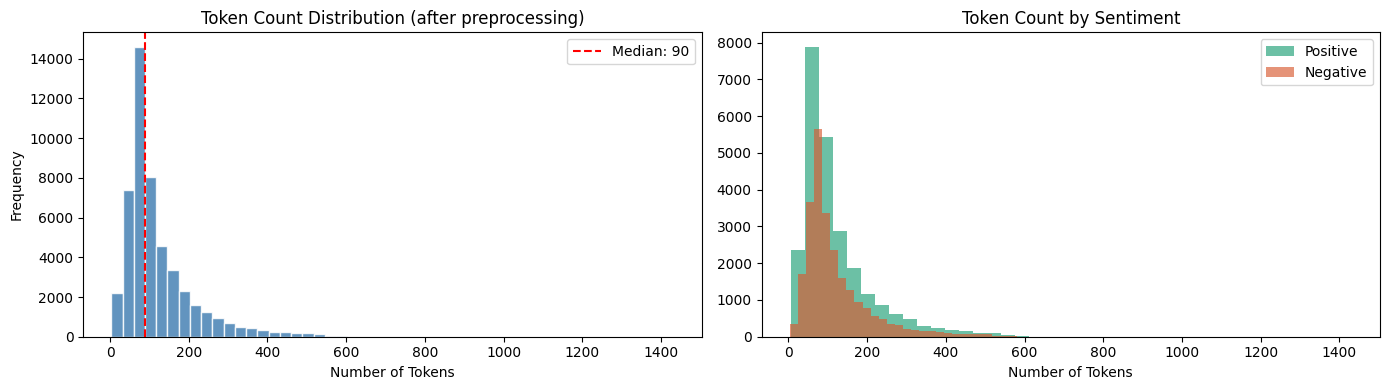

count    49396.0
mean       120.8
std         90.8
min          3.0
25%         65.0
50%         90.0
75%        147.0
max       1432.0
Name: token_count, dtype: float64


In [10]:
# ── Token count distribution ──
df['token_count'] = df['tokens_lemma'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution of token counts
axes[0].hist(df['token_count'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Token Count Distribution (after preprocessing)', fontsize=12)
axes[0].set_xlabel('Number of Tokens')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['token_count'].median(), color='red', linestyle='--', label=f'Median: {df["token_count"].median():.0f}')
axes[0].legend()

# Token count by sentiment
pos_tokens = df[df['label']==1]['token_count']
neg_tokens = df[df['label']==0]['token_count']
axes[1].hist(pos_tokens, bins=40, alpha=0.65, label='Positive', color='#1D9E75')
axes[1].hist(neg_tokens, bins=40, alpha=0.65, label='Negative', color='#D85A30')
axes[1].set_title('Token Count by Sentiment', fontsize=12)
axes[1].set_xlabel('Number of Tokens')
axes[1].legend()

plt.tight_layout()
plt.savefig('token_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(df['token_count'].describe().round(1))

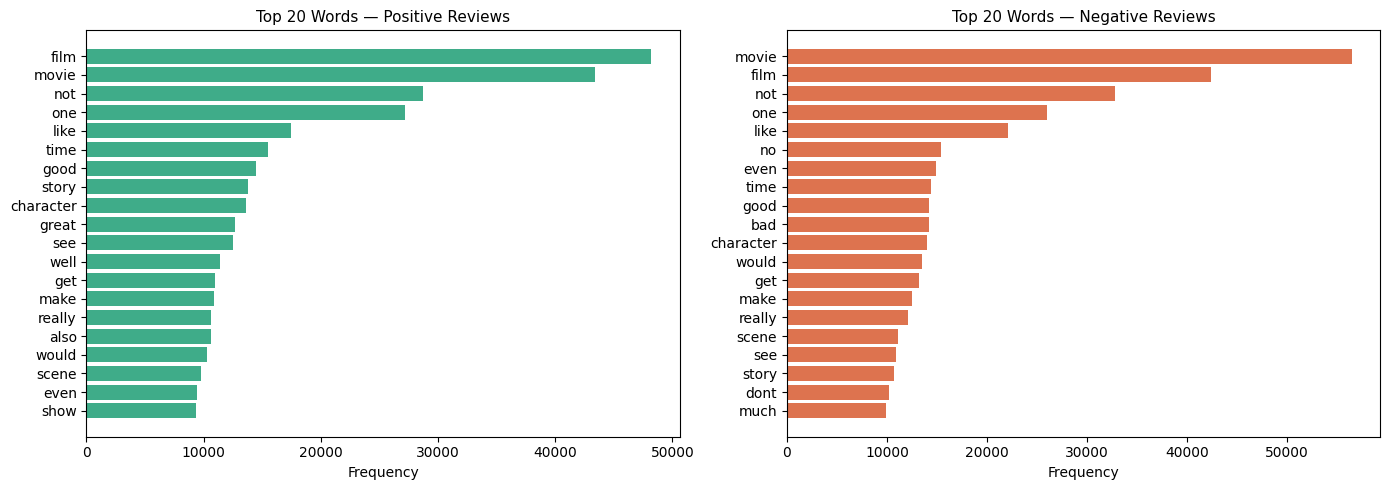

In [11]:
# ── Most common words per class ──
def get_top_words(df_subset, n=20):
    all_words = [word for tokens in df_subset['tokens_lemma'] for word in tokens]
    return Counter(all_words).most_common(n)

top_pos = get_top_words(df[df['label']==1])
top_neg = get_top_words(df[df['label']==0])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, top_words, title, color in [
    (axes[0], top_pos, 'Top 20 Words — Positive Reviews', '#1D9E75'),
    (axes[1], top_neg, 'Top 20 Words — Negative Reviews', '#D85A30')
]:
    words, counts = zip(*top_words)
    ax.barh(words[::-1], counts[::-1], color=color, alpha=0.85)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_words.png', dpi=150, bbox_inches='tight')
plt.show()

## 💾 Step 10 — Save Preprocessed Dataset

In [12]:
# Save the final preprocessed DataFrame
df_final = df[['review', 'sentiment', 'label', 'processed_text', 'token_count']]
df_final.to_csv('IMDB_Preprocessed.csv', index=False)

print('✅ Saved: IMDB_Preprocessed.csv')
print(f'\nFinal shape: {df_final.shape}')
print('\nColumns:')
for col in df_final.columns:
    print(f'  • {col}')
print('\nSample row:')
df_final.head(2)

✅ Saved: IMDB_Preprocessed.csv

Final shape: (49396, 5)

Columns:
  • review
  • sentiment
  • label
  • processed_text
  • token_count

Sample row:


,review,sentiment,label,processed_text,token_count
0,"$25,000 Pyramid Clues: Deep Blue Sea. Tremors....",negative,0,pyramid clue deep blue sea tremor slither eigh...,101
1,0.5/10. This movie has absolutely nothing good...,negative,0,movie absolutely nothing good acting among wor...,66


## ✅ Step 11 — Summary

In [13]:
print('='*55)
print('         PREPROCESSING SUMMARY')
print('='*55)
print(f'  Total reviews          : {len(df):,}')
print(f'  Positive               : {(df["label"]==1).sum():,}')
print(f'  Negative               : {(df["label"]==0).sum():,}')
print(f'  Avg tokens (raw)       : {df["tokens"].apply(len).mean():.0f}')
print(f'  Avg tokens (processed) : {df["token_count"].mean():.0f}')
print(f'  Null values            : {df_final.isnull().sum().sum()}')
print('='*55)

print('  Output: IMDB_Preprocessed.csv ✅')

         PREPROCESSING SUMMARY
  Total reviews          : 49,396
  Positive               : 24,698
  Negative               : 24,698
  Avg tokens (raw)       : 227
  Avg tokens (processed) : 121
  Null values            : 0
  Output: IMDB_Preprocessed.csv ✅


Step 12 — Feature Extraction


In [14]:
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X = vectorizer.fit_transform(df['processed_text'])
y = df['label']

print("Shape:", X.shape)

Shape: (49396, 5000)


Step 13 — Train-Test Split

In [15]:
# We split the dataset into training and testing sets:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% of data for testing
    random_state=42     # for reproducibility (same split every run)
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (39516, 5000)
Test shape: (9880, 5000)


**Step 14 — Model Training (Logistic Regression)**

1.   List item
2.   List item



In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("✅ Model training completed successfully!")


✅ Model training completed successfully!


In [17]:
import joblib
# Save trained model
joblib.dump(model, 'sentiment_model.pkl')
# Save TF-IDF vectorizer
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

print("✅ Model and Vectorizer saved!")

✅ Model and Vectorizer saved!


**Step 15 — Evaluation**

In [18]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predictions
y_pred = model.predict(X_test)
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("="*50)
print("Model Accuracy")
print("="*50)
print(f"Accuracy: {accuracy:.4f}")
print(f"Training Samples: {X_train.shape[0]}")
print(f"Testing Samples: {X_test.shape[0]}")
# Classification Report
print("\nClassification Report")
print("="*50)
print(classification_report(
    y_test,
    y_pred,
    target_names=["Negative", "Positive"]
))
# Confusion Matrix
print("\nConfusion Matrix")
print("="*50)
cm = confusion_matrix(y_test, y_pred)
print(cm)

Model Accuracy
Accuracy: 0.8961
Training Samples: 39516
Testing Samples: 9880

Classification Report
              precision    recall  f1-score   support

    Negative       0.91      0.88      0.89      4934
    Positive       0.89      0.91      0.90      4946

    accuracy                           0.90      9880
   macro avg       0.90      0.90      0.90      9880
weighted avg       0.90      0.90      0.90      9880


Confusion Matrix
[[4353  581]
 [ 446 4500]]


**Step 16 — Custom Prediction**

In [19]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    tokens = tokenize(cleaned)
    no_sw = remove_stopwords(tokens)
    lemmatized = lemmatize_tokens(no_sw)
    processed = ' '.join(lemmatized)

    vectorized = vectorizer.transform([processed])
    prediction = model.predict(vectorized)[0]

    return "Positive" if prediction == 1 else "Negative"

sample_review = "I absolutely loved this movie! The acting was superb."
print(f"Review: {sample_review}")
print(f"Predicted Sentiment: {predict_sentiment(sample_review)}")


Review: I absolutely loved this movie! The acting was superb.
Predicted Sentiment: Positive


**Step 17 — Advanced Evaluation**

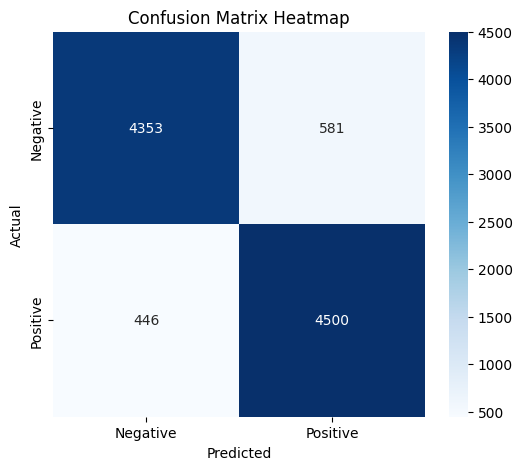

In [20]:
# Confusion Matrix Heatmap
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")

plt.show()

In [21]:
!pip install gradio -q

In [22]:
import gradio as gr

# دالة التوقع النهائية اللي بتربط كل الخطوات ببعض
def predict_sentiment_ui(text):
    if not text.strip():
        return "Please enter some text."

    # 1. التنظيف (من Step 4)
    cleaned = clean_text(text)
    # 2. التقطيع (من Step 5)
    tokens = tokenize(cleaned)
    # 3. حذف الكلمات الزائدة (من Step 6)
    no_sw = remove_stopwords(tokens)
    # 4. التوحيد (من Step 7)
    lemmatized = lemmatize_tokens(no_sw)
    # 5. دمج الكلمات (من Step 8)
    processed = ' '.join(lemmatized)

    # 6. التحويل لأرقام (Vectorization)
    vectorized = vectorizer.transform([processed])

    # 7. التوقع باستخدام الموديل (Model Prediction)
    prediction = model.predict(vectorized)[0]

    return "Positive ✅" if prediction == 1 else "Negative ❌"

In [23]:
# # إعداد واجهة Gradio
# interface = gr.Interface(
#     fn=predict_sentiment_ui, # الدالة اللي هتتنفذ لما نضغط زرار
#     inputs=gr.Textbox(lines=5, placeholder="Enter movie review here...", label="Movie Review"), # مدخلات النص
#     outputs=gr.Label(label="Sentiment Analysis Result"), # مخرج النتيجة
#     title="🎬 IMDB Sentiment Analysis UI",
#     description="Write a movie review in English, and the AI will tell you if it's Positive or Negative.",
#     theme="soft" # شكل الواجهة
# )

# # تشغيل الواجهة داخل Colab
# # interface.launch(share=True)
# interface.launch(share=True, debug=True)

# Deployment

In [25]:
!pip install gradio -q
import gradio as gr
import joblib
# Load saved files
model = joblib.load('sentiment_model.pkl')
vectorizer = joblib.load('tfidf_vectorizer.pkl')
# Prediction function
def predict_sentiment(text):
    # Cleaning
    cleaned = clean_text(text)
    # Tokenization
    tokens = tokenize(cleaned)
    # Remove stopwords
    no_sw = remove_stopwords(tokens)
    # Lemmatization
    lemmatized = lemmatize_tokens(no_sw)
    # Join text
    processed = ' '.join(lemmatized)
    # Vectorization
    vectorized = vectorizer.transform([processed])
    # Prediction
    prediction = model.predict(vectorized)[0]
    if prediction == 1:
        return "Positive Review ✅"
    else:
        return "Negative Review ❌"
# Gradio Interface
interface = gr.Interface(
    fn=predict_sentiment,

    inputs=gr.Textbox(
        lines=5,
        placeholder="Enter movie review here..."
    ),
    outputs="text",

    title="🎬 IMDB Sentiment Analysis",

    description="Write your review and AI will predict the sentiment."
)
# Launch app
interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4008093b4cb67900f5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
